# EDA - CNC Process Monitoring

- **Dataset:** Tnani et al. (2022) — CNC machining vibration, 3 machines, 15 processes, tri-axial accelerometer at 2 kHz
- **Labels:** good / bad
- **Objective:** Characterize data structure and signal properties before any feature extraction or modeling

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

from src.utils import data_loader_utils
from pathlib import Path

## Dataset Inventory

In [27]:
dataset_path = Path("../data/raw")

df = pd.DataFrame([
    {
        "machine":  h5_file.parts[-4],
        "process":  h5_file.parts[-3],
        "label":    h5_file.parts[-2],
        "filepath": str(h5_file)
    }
    for h5_file in dataset_path.rglob("*.h5")                          
])

df["machine_process"] = df["machine"] + "_" + df["process"]

display(df.head())
display(df.info())

,machine,process,label,filepath,machine_process
0,M01,OP03,bad,../data/raw/M01/OP03/bad/M01_Aug_2019_OP03_000.h5,M01_OP03
1,M01,OP03,good,../data/raw/M01/OP03/good/M01_Feb_2020_OP03_00...,M01_OP03
2,M01,OP03,good,../data/raw/M01/OP03/good/M01_Aug_2019_OP03_00...,M01_OP03
3,M01,OP03,good,../data/raw/M01/OP03/good/M01_Feb_2019_OP03_00...,M01_OP03
4,M01,OP03,good,../data/raw/M01/OP03/good/M01_Feb_2020_OP03_00...,M01_OP03


<class 'pandas.DataFrame'>
RangeIndex: 1702 entries, 0 to 1701
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   machine          1702 non-null   str  
 1   process          1702 non-null   str  
 2   label            1702 non-null   str  
 3   filepath         1702 non-null   str  
 4   machine_process  1702 non-null   str  
dtypes: str(5)
memory usage: 66.6 KB


None

In [28]:
df.groupby(["machine", "label"]).size().unstack(fill_value=0)

label,bad,good
machine,,
M01,34,485
M02,27,617
M03,9,530


In [29]:
df.groupby("machine")["process"].nunique()

machine
M01    15
M02    15
M03    14
Name: process, dtype: int64

In [30]:
data = data_loader_utils.datafile_read(df["filepath"].iloc[0], plotting=False)
print(data.shape)

(139653, 3)


- 1,702 HDF5 files confirmed across M01, M02, M03 which matches the paper's reported total
- All files are valid numpy arrays of shape `(n_samples, 3)`, confirming tri-axial accelerometer structure at 2 kHz
- M03 contains 14 processes instead of 15, OP14 is intentionally excluded due to confidentiality constraints (Biegel et al., 2024)

# Class Distribution

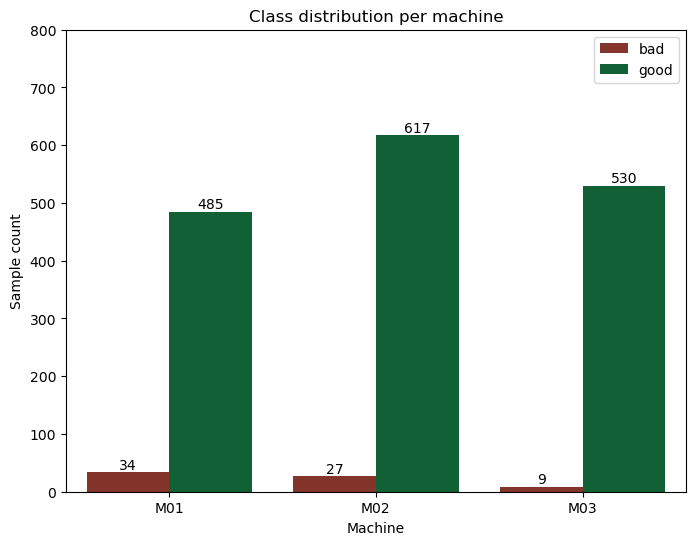

Global imbalance — good: 1632 (95.89% good) | Bad: 70 (4.11% bad)


In [31]:

summary_machine = df.groupby(["machine", "label"]).size().reset_index(name="count")

PALETTE     = {"good": "#056D33", "bad": "#92281c"}

fig, ax = plt.subplots(figsize=(8, 6))

ax = sns.barplot(data=summary_machine, x="machine", y="count", hue="label",
            palette=PALETTE)
ax.set_title("Class distribution per machine")
ax.set_xlabel("Machine")
ax.set_ylabel("Sample count")
ax.legend(loc="best")
ax.set_ylim(0, 800)

for container in ax.containers:
    ax.bar_label(container)

plt.show()

ratio = df["label"].value_counts()
print(f"Global imbalance — good: {ratio['good']} ({ratio['good']/len(df):.2%} good) | Bad: {ratio['bad']} ({ratio['bad']/len(df):.2%} bad)")

- ~4% bad samples globally with severe class imbalance
- M01 carries the most bad samples (34), M03 the fewest (9) and the machine-out test set has very limited anomaly coverage
- Process-level breakdown omitted — labels shuffled per machine, bad rates carry no transferable meaning

**Strategy:** class weights + SMOTE applied to training data only


## Raw Signal Characterization

### Signal Duration

In [ ]:
SAMPLING_RATE_HZ = 2000

df["duration_s"] = df["filepath"].apply(
    lambda p: data_loader_utils.datafile_read(p, plotting=False).shape[0] / SAMPLING_RATE_HZ
)

In [41]:
df.groupby("label")["duration_s"].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
bad,70.0,40.14,23.29,13.40,21.76,35.93,52.10,130.00
good,1632.0,53.00,30.41,18.43,32.26,44.03,65.66,158.72


In [34]:
df.groupby(["machine", "label"])["duration_s"].describe().round(2)

count   mean    std    min    25%    50%    75%     max
machine label                                                         
M01     bad     34.0  42.53  23.91  13.40  23.14  40.86  53.58   96.95
        good   485.0  54.88  31.62  18.94  32.77  44.54  68.61  136.70
M02     bad     27.0  39.77  24.22  15.02  23.33  35.00  47.36  130.00
        good   617.0  52.07  29.65  18.43  32.40  44.03  59.90  158.72
M03     bad      9.0  32.24  17.83  14.74  18.00  22.00  45.00   60.00
        good   530.0  52.36  30.13  18.94  29.18  43.26  65.02  134.14

- Bad samples are ~24% shorter on average (40.1s vs 53.0s) and also consistent across M01 and M03, but high variance on M02 (std 24.2s) weakens the pattern there
- Likely cause: anomalies interrupt process runs early, producing shorter recordings
- Duration correlates with label through a physical mechanism, not vibration content, a model seeing length-dependent features would exploit this instead of learning fault signatures

**Strategy:** use only length-independent features (RMS, kurtosis, mean, std) and never sums or totals

### Waveform Analysis

In [35]:
df[df["label"] == "bad"].groupby("machine_process").size().sort_values(ascending=False).head(10)

machine_process
M01_OP10    4
M01_OP06    4
M01_OP11    4
M01_OP07    4
M02_OP08    4
M01_OP05    4
M01_OP08    3
M02_OP07    3
M03_OP07    3
M01_OP12    3
dtype: int64

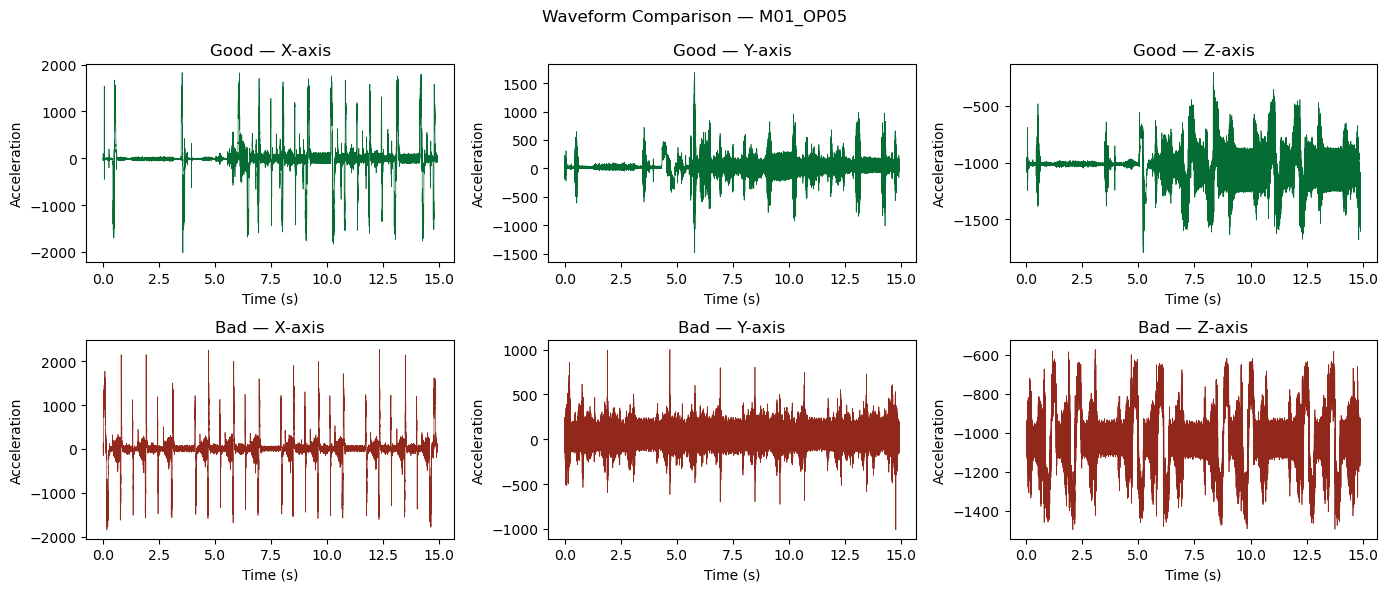

In [44]:
MACHINE_PROCESS = "M01_OP05"

mp          = df[df["machine_process"] == MACHINE_PROCESS]
good_signal = data_loader_utils.datafile_read(mp[mp["label"] == "good"]["filepath"].iloc[0], plotting=False)
bad_signal  = data_loader_utils.datafile_read(mp[mp["label"] == "bad"]["filepath"].iloc[0],  plotting=False)

n_samples   = min(len(good_signal), len(bad_signal))
good_signal = good_signal[:n_samples]
bad_signal  = bad_signal[:n_samples]
t           = np.arange(n_samples) / SAMPLING_RATE_HZ

fig, axs = plt.subplots(2, 3, figsize=(14, 6))

for i, axis in enumerate(["X", "Y", "Z"]):
    axs[0, i].plot(t, good_signal[:, i], color=PALETTE["good"], linewidth=0.5)
    axs[0, i].set_title(f"Good — {axis}-axis")
    axs[1, i].plot(t, bad_signal[:, i],  color=PALETTE["bad"],  linewidth=0.5)
    axs[1, i].set_title(f"Bad — {axis}-axis")

for ax in axs.flat:
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Acceleration")

fig.suptitle(f"Waveform Comparison — {MACHINE_PROCESS}", fontsize=12)
plt.tight_layout()
plt.show()

- Z-axis shows a persistent offset (~−1000) on both labels — likely gravitational pull, introducing baseline instability and non-stationarity
- Bad samples show elevated baseline noise and less structured periodicity across all axes — consistent with non-Gaussian, impulsive vibration behavior

**Stategy:** DC offset removal required on Z-axis before feature extraction

### Time-Domain Statistics

In [38]:
from scipy.stats import kurtosis, skew

def compute_time_domain_stats(path):
    data = datafile_read(path, plotting=False)
    stats = {}
    for i, axis in enumerate(["x", "y", "z"]):
        signal = data[:, i]
        stats[f"rms_{axis}"]      = np.sqrt(np.mean(signal ** 2))
        stats[f"std_{axis}"]      = signal.std()
        stats[f"kurtosis_{axis}"] = kurtosis(signal)
        stats[f"skewness_{axis}"] = skew(signal)
    return stats

td_stats = df["filepath"].apply(compute_time_domain_stats).apply(pd.Series)
df = pd.concat([df, td_stats], axis=1)

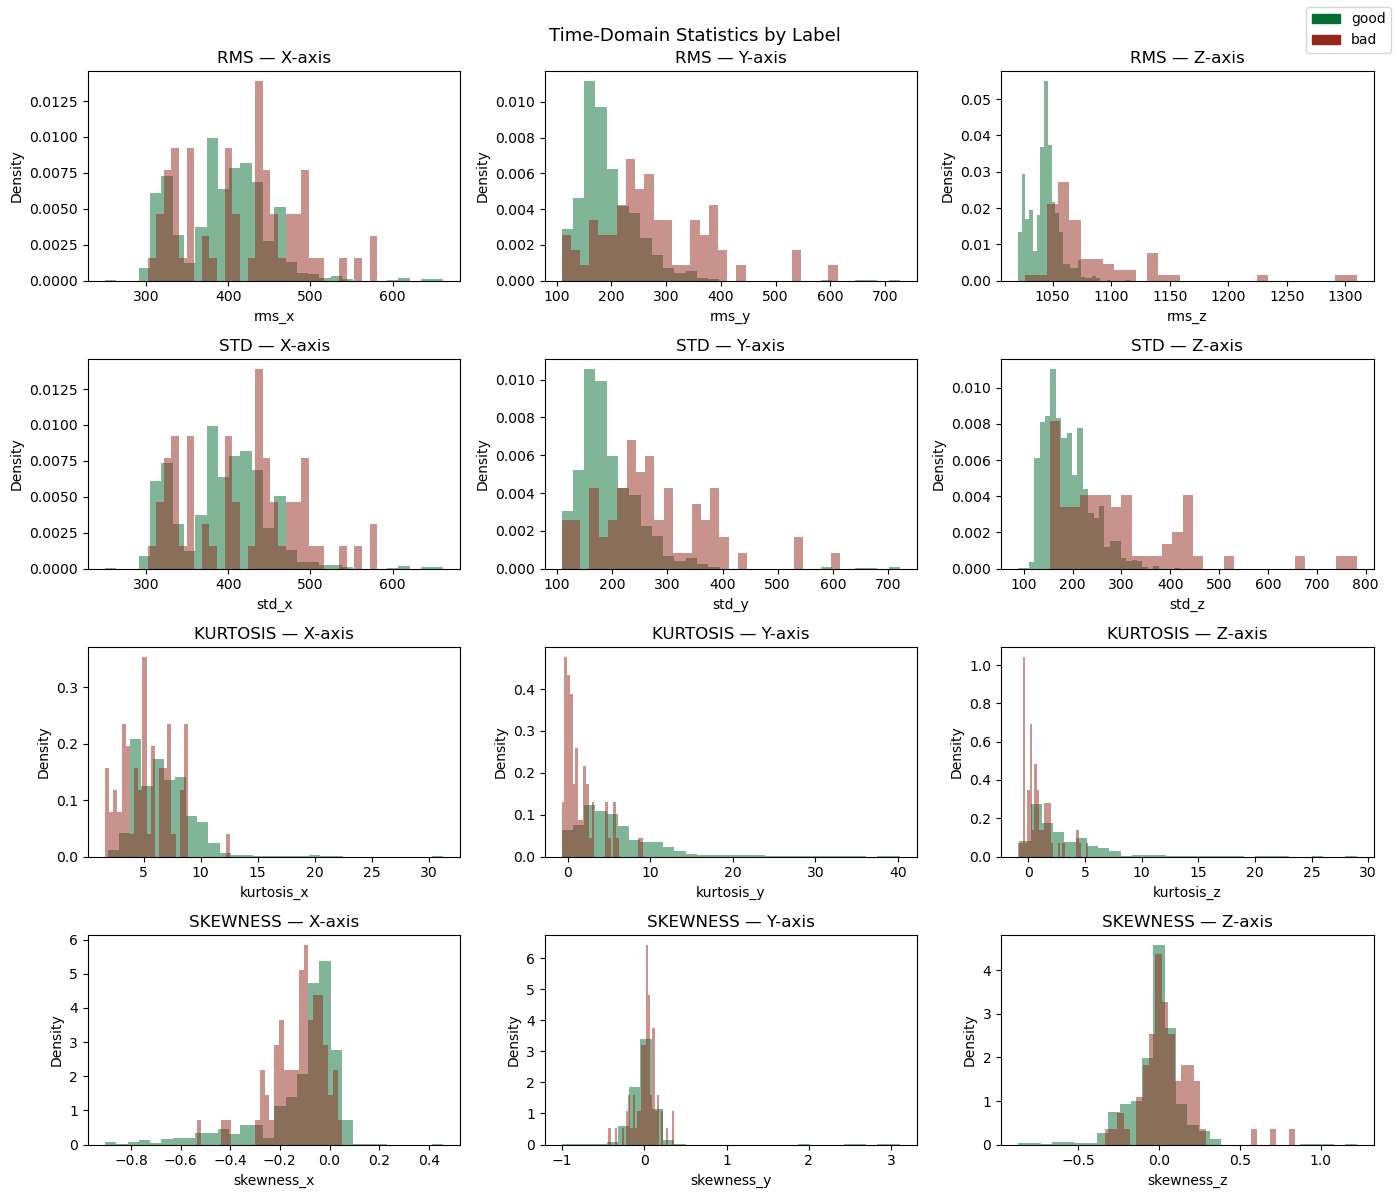

In [39]:
stats    = ["rms", "std", "kurtosis", "skewness"]
axes     = ["x", "y", "z"]

fig, axs = plt.subplots(len(stats), len(axes), figsize=(14, 12))

for i, stat in enumerate(stats):
    for j, axis in enumerate(axes):
        col = f"{stat}_{axis}"
        for label, color in PALETTE.items():
            subset = df[df["label"] == label][col]
            axs[i, j].hist(subset, bins=30, alpha=0.5, color=color, 
                          label=label, density=True)
        axs[i, j].set_title(f"{stat.upper()} — {axis.upper()}-axis")
        axs[i, j].set_xlabel(col)
        axs[i, j].set_ylabel("Density")

handles = [plt.Rectangle((0,0),1,1, color=c) for c in PALETTE.values()]
fig.legend(handles, PALETTE.keys(), loc="upper right")
fig.suptitle("Time-Domain Statistics by Label", fontsize=13)
plt.tight_layout()
plt.show()

In [40]:
stat_cols = [f"{s}_{a}" for s in ["rms", "std", "kurtosis", "skewness"] for a in ["x", "y", "z"]]
df.groupby("label")[stat_cols].mean().round(2)

,rms_x,rms_y,rms_z,std_x,std_y,std_z,kurtosis_x,kurtosis_y,kurtosis_z,skewness_x,skewness_y,skewness_z
label,,,,,,,,,,,,
bad,416.67,276.40,1083.00,416.51,275.08,293.19,5.31,1.56,0.78,-0.13,0.02,0.06
good,393.81,194.49,1042.87,393.75,193.23,190.28,6.78,5.97,2.93,-0.12,-0.00,-0.02


- RMS and STD on X and Y show partial class separation — bad samples carry higher energy
- Z RMS is dominated by the DC offset and is uninformative pre-preprocessing
- Kurtosis on X and Y is elevated for bad samples — consistent with impulsive fault-induced vibration
- Skewness shows no class separation across all axes — excluded from feature set

**Strategy:** RMS, STD, and kurtosis retained as candidate features; skewness dropped; Z-axis features deferred until after DC offset removal